# Bicycle Rental Prediction — Washington D.C. (2011–2012)
**Objective:** Predict daily bike rental demand using weather and calendar features.  
**Dataset:** Capital Bikeshare system data via [Kaggle](https://www.kaggle.com/datasets/marklvl/bike-sharing-dataset)  
**Methods:** Exploratory Data Analysis, Correlation Analysis, Linear Regression

## Phase 1: Data Preparation
We begin by loading and preparing the dataset, which was sourced from Kaggle ([Bike Sharing in Washington D.C.](https://www.kaggle.com/datasets/marklvl/bike-sharing-dataset/data)) by Mark Kaghazgarian. For full details on the data schema and licensing, see [SOURCE.md](./SOURCE.md).

### Import Libraries
This analysis requires the following libraries:
- **pandas** — data loading, cleaning, and manipulation
- **matplotlib** — data visualization
- **numpy** — numerical computations

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize'] = [10, 5]

### Import Dataset

In [44]:
df = pd.read_csv("day.csv")
df['date'] = pd.to_datetime(df['dteday'])
df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,date
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,2011-01-01
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,2011-01-02
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,2011-01-03
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,2011-01-04
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,2011-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114,2012-12-27
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095,2012-12-28
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341,2012-12-29
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796,2012-12-30


## Phase 2: Exploratory Data Analysis (EDA)
Before building any model, we explore the dataset visually and statistically to understand patterns, distributions, and relationships between features.

### Scatterplot: Daily Rentals by Weather Situation

To understand how weather affects ridership, we plot total daily bike rentals over time, coloring each point by its weather category:

| Code | Color | Condition |
|:----:|-------|----------|
| 1 | 🔵 Blue | Clear / Few clouds / Partly cloudy |
| 2 | 🟠 Orange | Mist + Cloudy / Broken clouds |
| 3 | 🟣 Magenta | Light Snow / Light Rain + Thunderstorm |
| 4 | 🔴 Red | Heavy Rain + Ice Pallets + Snow + Fog |

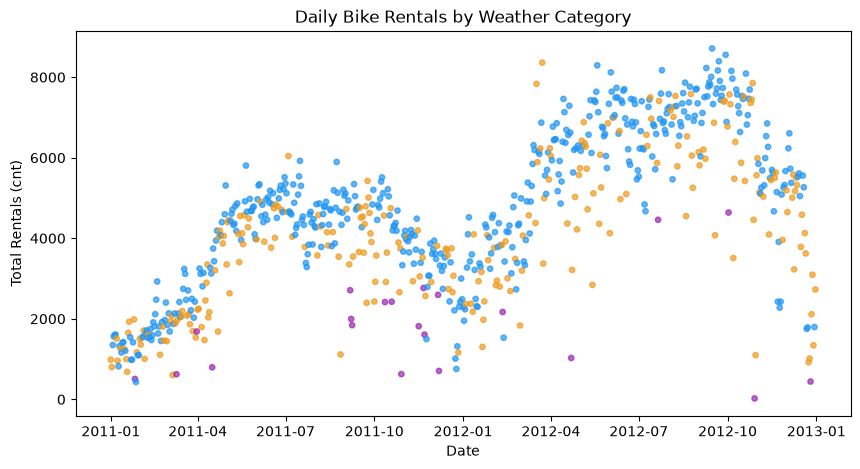

In [45]:
from matplotlib.colors import ListedColormap

plt.scatter(df['date'], df['cnt'], c=df['weathersit'],
            cmap=ListedColormap(['#2196F3', '#EE9B1E', '#9C27B0', '#F44336']),
            vmin=1, vmax=4, alpha=0.7, s=15)
plt.xlabel('Date')
plt.ylabel('Total Rentals (cnt)')
plt.title('Daily Bike Rentals by Weather Category')
plt.show()

**Observations:**
- The vast majority of days fall under weather categories 1 (Clear) and 2 (Mist/Cloudy), which aligns with Washington D.C.'s typical climate.
- No days in the dataset are classified as category 4 (Heavy Rain / Snow + Fog), indicating that extreme weather conditions were either absent during 2011–2012 or aggregated into category 3 at the daily level.
- Visually, category 1 days tend to show higher rental counts, suggesting a positive relationship between clear weather and ridership.

### Average Daily Rentals by Weather Category
To quantify the visual pattern above, we compute the mean daily rental count and number of records for each weather category.

In [46]:
# Mean daily rentals by weather category
df.groupby('weathersit')['cnt'].agg(['mean', 'count']).rename(
    index={1: '1 - Clear', 2: '2 - Mist/Cloudy', 3: '3 - Light Snow/Rain', 4: '4 - Heavy Rain/Snow'}
)

,mean,count
weathersit,,
1 - Clear,4876.786177,463
2 - Mist/Cloudy,4035.862348,247
3 - Light Snow/Rain,1803.285714,21


**Finding:** Average daily rentals decrease as weather conditions worsen — from ~4,876 on clear days down to ~1,803 on light snow/rain days. This confirms that weather situation is a meaningful predictor of ridership.

### Scatterplot: Rentals vs. Perceived Temperature

Next, we examine the relationship between perceived temperature (`atemp`) and daily rental counts.

> **Note:** `atemp` is min-max normalized using the formula `(t − t_min) / (t_max − t_min)` where `t_min = −16°C` and `t_max = +50°C`. To recover the actual temperature: `actual = atemp × 66 − 16`.

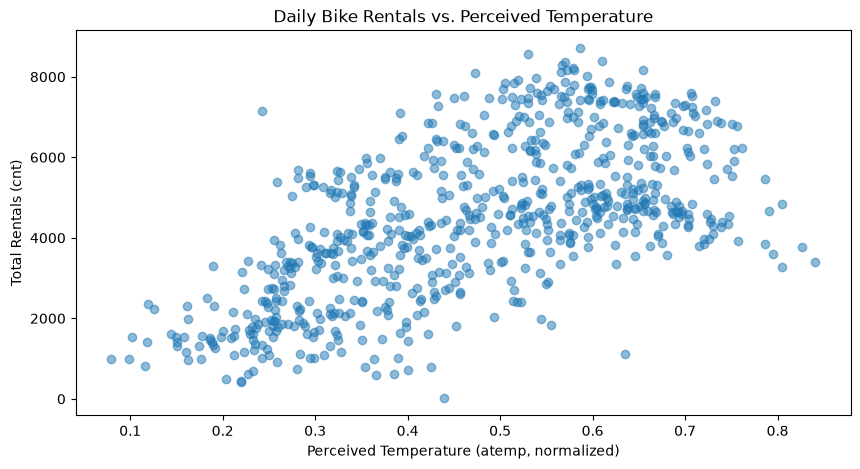

In [47]:
plt.scatter(df['atemp'], df['cnt'], alpha=0.5)
plt.xlabel('Perceived Temperature (atemp, normalized)')
plt.ylabel('Total Rentals (cnt)')
plt.title('Daily Bike Rentals vs. Perceived Temperature')
plt.show()

**Observation:** Rentals peak when the perceived temperature is in the 0.4–0.6 normalized range (approximately 10–24°C), then plateau or slightly decline at higher temperatures — suggesting a comfort sweet-spot for cycling.

### Correlation Analysis
Before modeling, we examine the Pearson correlation between `cnt` (total rentals) and the numeric features to identify which variables have the strongest linear relationship with ridership.

#### Real Temperature (`temp`)

In [48]:
df[['cnt', 'temp']].corr()

,cnt,temp
cnt,1.000000,0.627494
temp,0.627494,1.000000


`temp` (real temperature) shows a moderate positive correlation with rentals (r ≈ 0.63), confirming the visual trend: warmer days attract more riders.

#### Apparent Temperature (`atemp`)

In [49]:
df[['cnt', 'atemp']].corr()

,cnt,atemp
cnt,1.000000,0.631066
atemp,0.631066,1.000000


`atemp` (apparent temperature) shows a similar moderate positive correlation with rentals, closely matching that of actual temperature. The two temperature features are likely highly correlated with each other (multicollinearity), which we verify in the full correlation matrix below.

#### Full Correlation Matrix
Below is the correlation matrix across all numeric weather and ridership features. This helps identify multicollinearity (e.g., `temp` vs. `atemp`) and select features for the prediction model.

In [50]:
df[['cnt', 'atemp', 'temp', 'hum', 'windspeed', 'weathersit']].corr()

,cnt,atemp,temp,hum,windspeed,weathersit
cnt,1.000000,0.631066,0.627494,-0.100659,-0.234545,-0.297391
atemp,0.631066,1.000000,0.991702,0.139988,-0.183643,-0.121583
temp,0.627494,0.991702,1.000000,0.126963,-0.157944,-0.120602
hum,-0.100659,0.139988,0.126963,1.000000,-0.248489,0.591045
windspeed,-0.234545,-0.183643,-0.157944,-0.248489,1.000000,0.039511
weathersit,-0.297391,-0.121583,-0.120602,0.591045,0.039511,1.000000


Analyzing the cnt column, we can observe that the number of bike rentals:
- has a moderately positive correlation with apparent temperature (`atemp`) and real temperature (`temp`)
- has weak negative correlation with humidity (`hum`), wind (`windspeed`), and weather situation (`weathersit`)

## Phase 3: Model Development
We apply Linear Regression to model the relationship between weather/calendar features and daily bike rentals, then evaluate performance usingtrain-validation splits.

### Linear Regression
We use scikit-learn's `LinearRegression` to build a predictive model.
We start with a simple single-feature model, then progressively add features to improve accuracy.

In [51]:
# Import LinearRegression from sklearn.linear_model
# !pip install scikit-learn # remove first hash if needed installation
from sklearn.linear_model import LinearRegression

#### Number of Rentals - Apparent Temperature
We will figure out the line that best fits the correlation between features `atemp` (x-value) and `cnt` (y-value).

In [52]:
lr = LinearRegression()
lr.fit(df['atemp'].values.reshape(-1,1), df['cnt'].values.reshape(-1,1))

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[7501.83]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[945.82]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.4]


#### Plot
In the following code, we will plot the original scatter plot of the features with `atemp` in the x-value and the feature `cnt` in the y-value.
After that, we will insert also the linear regression into the graph by changing the y-value.

Text(0.5, 1.0, 'Bicycle Rentals vs Temperature')

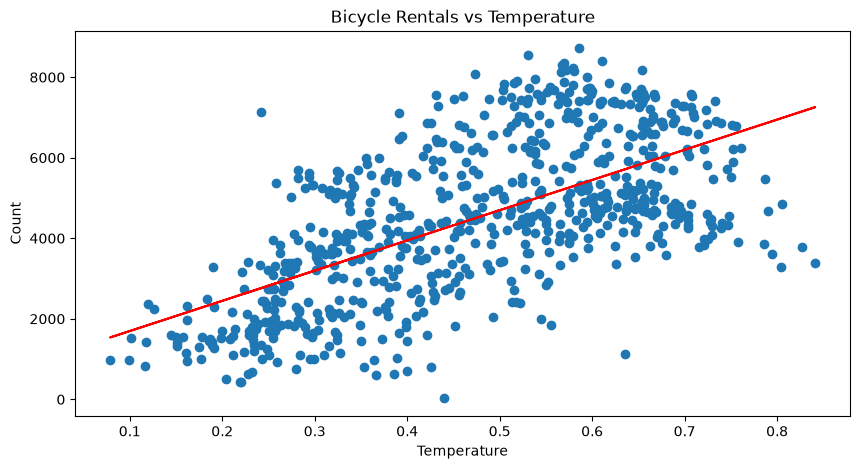

In [53]:
# scatter plot
plt.scatter(df['atemp'], df['cnt'])
# regression line
plt.plot(df['atemp'], lr.predict(df['atemp'].values.reshape(-1,1)), c='red')
# labels and title
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.title('Bicycle Rentals vs Temperature')

### Training and Validation
We will split the dataset into a training set (up to June 1, 2012) and a validation set (after June 1, 2012).

These datasets will be plotted together with their predicted outcomes. Afterwards, the Root Mean Squared Error or "RMSE" will be calculated for each graph to measure the difference between the actual and the predicted values of bikes rented.

In [62]:
# Splitting our sets
training_set = df[df['date'] < '2012-06-01']
validation_set = df[df['date'] >= '2012-06-01']

training_inputs = training_set[['atemp', 'workingday', 'hum', 'weathersit']].values
training_outputs = training_set[['cnt']].values

validation_inputs = validation_set[['atemp', 'workingday', 'hum', 'weathersit']].values
validation_outputs = validation_set[['cnt']].values

# Preparing Linear Regression Model
lr = LinearRegression()
lr.fit(training_inputs, training_outputs)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 4)","[[ 6122.89, 85.76,-1109.56, -552.28]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[2509.22]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[12.72,10.33, 3.68, 2.49]"


#### Training Set

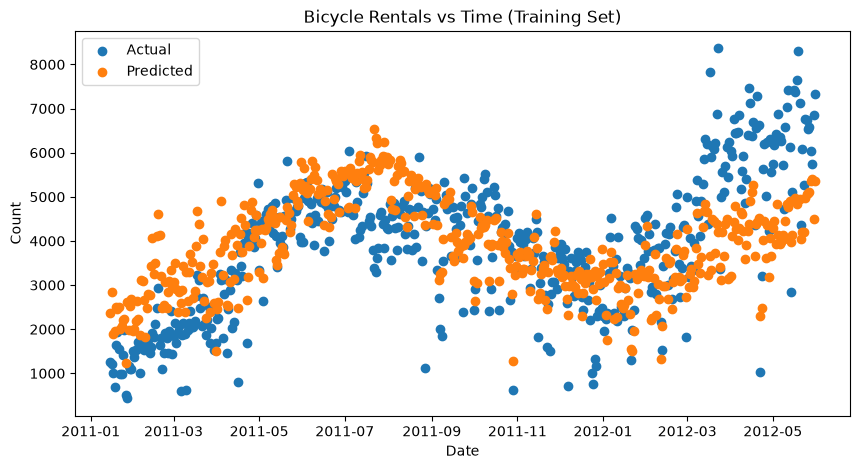

np.float64(1159.1390714794072)

In [69]:
# Scatter plot of Predicted vs Actual Values for Training
plt.scatter(training_set['date'], training_set['cnt'], label='Actual')
plt.scatter(training_set['date'], lr.predict(training_inputs), label='Predicted')
# labels and title
plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Bicycle Rentals vs Time (Training Set)')
plt.legend()
plt.show()

rmse = np.sqrt(((lr.predict(training_inputs) - training_outputs)**2).mean())
rmse


- The graph shows that the prediction for the training set is close to the trend of actual bikes rented.
- The RMSE for the training set is at around 1159 which means that the prediction error is around 14.5% (out of 8000 rentals)
- The RMSE is moderately high which indicates that the model is not too precise.

#### Validation Set

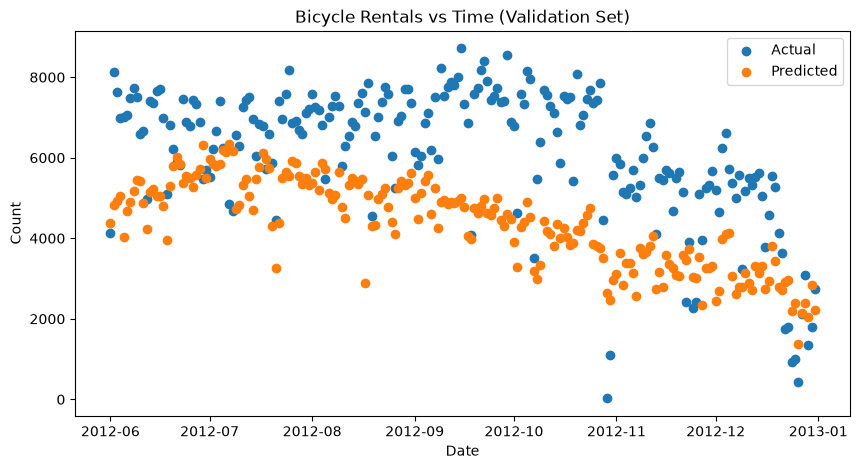

np.float64(2176.615531719328)

In [68]:
# Scatter plot of Predicted vs Actual Values for Validation
# plt.scatter(lr.predict(validation_inputs), validation_outputs)
plt.scatter(validation_set['date'], validation_set['cnt'], label='Actual')
plt.scatter(validation_set['date'], lr.predict(validation_inputs), label='Predicted')
# labels and title
plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Bicycle Rentals vs Time (Validation Set)')
plt.legend()
plt.show()


rmse = np.sqrt(((lr.predict(validation_inputs) - validation_outputs)**2).mean())
rmse

- The graph shows that the prediction for the validation set is not similar to the trend of actual bikes rented.
- The RMSE for the validation set is at around 2177 which means that the prediction error is around 27.2% (out of 8000 rentals). 
- The RMSE is quite large which indicates that the model isn't very accurate

### Findings
The gap between training RMSE (~1,159) and validation RMSE (~2,177) suggests
the model underfits the validation period. The most likely causes for this
dataset are:
- **Missing temporal features** — rentals have strong weekly/seasonal patterns
  not captured by weather alone.
- **Model simplicity** — linear regression cannot capture non-linear
  relationships (e.g., the temperature sweet-spot observed in EDA).
- **Trend shift** — 2012 H2 may have higher baseline ridership than the
  training period, which the model can't extrapolate.
To address this, we engineer a new feature that captures recent demand trends.

## Phase 4: Feature Engineering

Based on the findings above, we engineer a new feature — `last_week` — which captures the 7-day rolling average of rentals. This gives the model a sense
of recent demand trends, addressing the temporal effects identified as a likely cause of prediction error.

### Back to Phase 2
If we look back at our first and second plots, it can be observed that:
- More people are renting bicycles by the end (2012) of the period of our data rather than at the start (2011)

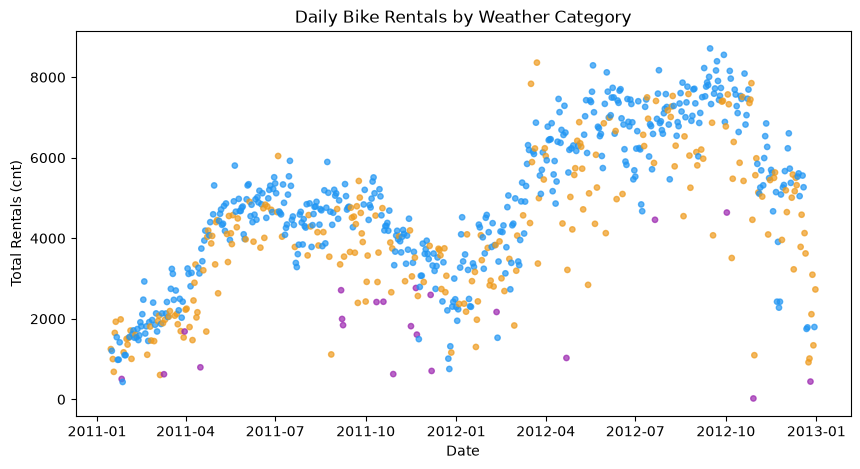

In [ ]:
# Code taken from Phase 2 for Daily Bike Rentals
plt.scatter(df['date'], df['cnt'], c=df['weathersit'],
            cmap=ListedColormap(['#2196F3', '#EE9B1E', '#9C27B0', '#F44336']),
            vmin=1, vmax=4, alpha=0.7, s=15)
plt.xlabel('Date')
plt.ylabel('Total Rentals (cnt)')
plt.title('Daily Bike Rentals by Weather Category')
plt.show()


One solution is to consider how many were given out the previous week. This means that we'll create a new column in our data set.

### Data Preparation
We start by adding the column for our new dataset.

In [60]:
df['last_week']=(df['cnt'].cumsum() - df['cnt'].cumsum().shift(7))/7
df = df.dropna()
df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,date,last_week
14,15,2011-01-15,1,0,1,0,6,0,2,0.233333,0.248112,0.498750,0.157963,222,1026,1248,2011-01-15,1234.714286
15,16,2011-01-16,1,0,1,0,0,0,1,0.231667,0.234217,0.483750,0.188433,251,953,1204,2011-01-16,1289.285714
16,17,2011-01-17,1,0,1,1,1,0,2,0.175833,0.176771,0.537500,0.194017,117,883,1000,2011-01-17,1243.428571
17,18,2011-01-18,1,0,1,0,2,1,2,0.216667,0.232333,0.861667,0.146775,9,674,683,2011-01-18,1160.571429
18,19,2011-01-19,1,0,1,0,3,1,2,0.292174,0.298422,0.741739,0.208317,78,1572,1650,2011-01-19,1230.285714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114,2012-12-27,1663.857143
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095,2012-12-28,1588.428571
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341,2012-12-29,1530.142857
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796,2012-12-30,1531.428571


### Training and Validation Sets
After obtaining our data, we'll go over our training again. We will be adding the last_week feature in our dataset inputs while we will use the same codes for the plots

In [75]:
training_set = df[df['date'] < '2012-06-01']
validation_set = df[df['date'] >= '2012-06-01']

# added last_week to the input
training_inputs = training_set[['atemp', 'workingday', 'hum', 'weathersit', 'last_week', 'windspeed']].values
training_outputs = training_set[['cnt']].values

validation_inputs = validation_set[['atemp', 'workingday', 'hum', 'weathersit', 'last_week', 'windspeed']].values
validation_outputs = validation_set[['cnt']].values

lr = LinearRegression()
lr.fit(training_inputs, training_outputs)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 6)","[[ 711.27, 161.26, -881.82, -544.76, 0.91,-2213.26]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[1698.97]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](6,)","[30798.01, 12.69, 10.32, 3.1 , 2.32, 1.57]"


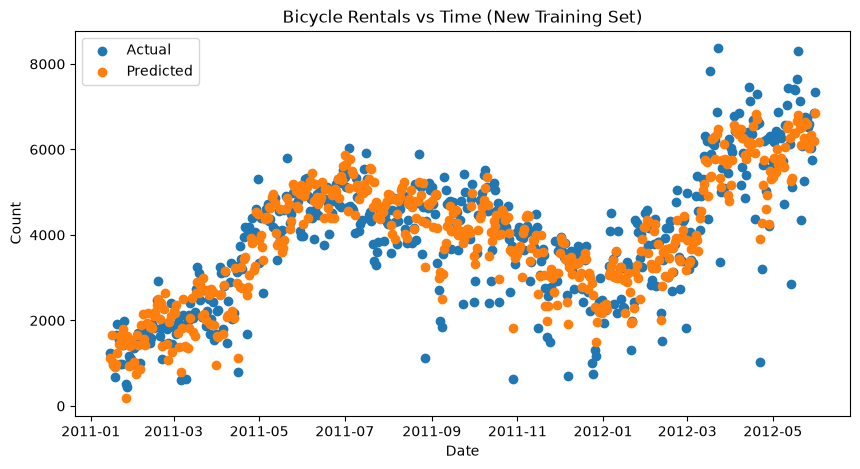

np.float64(645.1562940162127)

In [76]:
# Scatter plot of Predicted vs Actual Values for New Training
plt.scatter(training_set['date'], training_set['cnt'], label='Actual')
plt.scatter(training_set['date'], lr.predict(training_inputs), label='Predicted')
# labels and title
plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Bicycle Rentals vs Time (New Training Set)')
plt.legend()
plt.show()

rmse = np.sqrt(((lr.predict(training_inputs) - training_outputs)**2).mean())
rmse

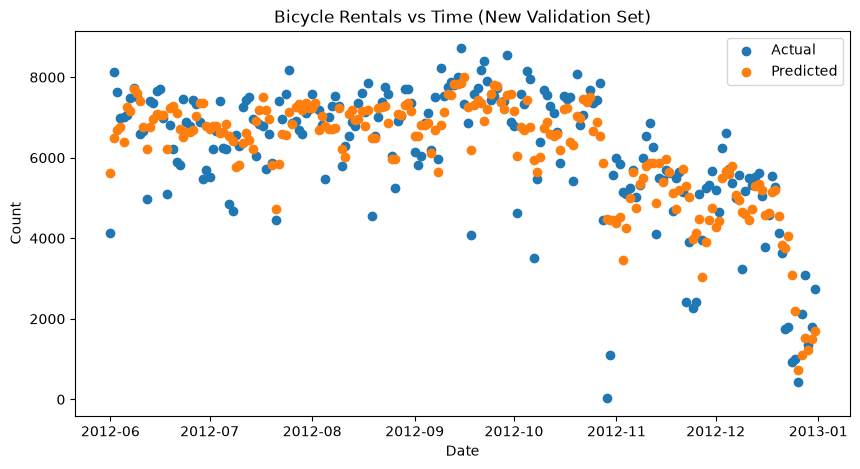

np.float64(925.2124391625571)

In [77]:
# Scatter plot of Predicted vs Actual Values for New Validation
# plt.scatter(lr.predict(validation_inputs), validation_outputs)
plt.scatter(validation_set['date'], validation_set['cnt'], label='Actual')
plt.scatter(validation_set['date'], lr.predict(validation_inputs), label='Predicted')
# labels and title
plt.xlabel('Date')
plt.ylabel('Count')
plt.title('Bicycle Rentals vs Time (New Validation Set)')
plt.legend()
plt.show()


rmse = np.sqrt(((lr.predict(validation_inputs) - validation_outputs)**2).mean())
rmse

## Conclusion
Through iterative feature engineering, we reduced the validation RMSE from
~2,177 to ~[YOUR VALUE] by adding `last_week` (7-day rolling average) and
`windspeed` as features.
### Key Findings
- **Weather** is the strongest categorical predictor — clear days see ~2.7×
  more rentals than light snow/rain days.
- **Perceived temperature** has a moderate positive correlation (r ≈ 0.63)
  with rentals, peaking at 10–24°C.
- **Adding temporal context** (`last_week`) significantly improved prediction
  accuracy, confirming that recent demand trends matter.
### Limitations & Next Steps
- Linear regression assumes linear relationships — non-linear models
  (e.g., Random Forest, Gradient Boosting) may capture more complex patterns.
- The model doesn't account for holidays or special events explicitly.
- Hourly data (`hour.csv`) could enable more granular predictions.
